In [ ]:
import argparse
import os
import numpy as np
import math
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import datasets
from torch.autograd import Variable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "gpu")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rumiyyaalili","key":"5a48756827bd010b7b5a1f5561da34e8"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rumiyyaalili/rumiyya-256

Dataset URL: https://www.kaggle.com/datasets/rumiyyaalili/rumiyya-256
License(s): unknown
 97% 34.0M/34.9M [00:02<00:00, 23.1MB/s]
100% 34.9M/34.9M [00:02<00:00, 13.8MB/s]


In [ ]:
!unzip -qq rumiyya-256

In [ ]:
import os

dataset_path = "/content/preprocessed_images"
extensions = (".png", ".jpg", ".jpeg")

# Count all image files recursively
total_images = 0
for root, _, files in os.walk(dataset_path):
    total_images += sum(file.lower().endswith(extensions) for file in files)

print(f"Total number of images in the dataset: {total_images}")

Total number of images in the dataset: 2842


In [ ]:
# Create directories
os.makedirs("images", exist_ok=True)

In [ ]:
# Set parameters
n_epochs = 150  # Number of epochs of training
batch_size = 32  # Size of the batches
lr_g = 0.002  # Adam: learning rate for generator
lr_d = 0.005 # learning rate for discriminator
b1 = 0.9  # Adam: decay of first-order momentum of gradient
b2 = 0.999  # Adam: decay of second-order momentum of gradient
latent_dim = 256  # Dimensionality of the latent space
img_size = 256  # Size of each image dimension
channels = 1  # Number of image channels (grayscale)
n_critic = 10  # Number of training steps for discriminator per iteration
clip_value = 0.01  # Lower and upper clip values for discriminator weights
sample_interval = 400  # Interval between image samples
lambda_gp = 2.0 # Define the gradient penalty weight

In [ ]:
img_shape = (channels, img_size, img_size)
cuda = True if torch.cuda.is_available() else False

In [ ]:
import torch.nn as nn
import numpy as np

class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape  # Expected shape: (channels, height, width)
        self.channels = img_shape[0]  # Extract channels

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        # Fully connected part
        self.model_fc = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()
        )

        # Convolutional refinement part
        self.conv_refine = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        # Generate image from latent vector
        img = self.model_fc(z)

        # Ensure correct shape: (batch_size, channels, height, width)
        img = img.view(img.shape[0], self.channels, self.img_shape[1], self.img_shape[2])

        # Apply CNN refinement
        img = self.conv_refine(img)

        return img

In [ ]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_shape):
        super(Discriminator, self).__init__()
        self.img_shape = img_shape  # (channels, height, width)

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Dynamically calculate the flattened feature size
        self.flattened_size = self._get_flattened_size()

        self.fc_layers = nn.Sequential(
            nn.Linear(self.flattened_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1)  # Output a single value (real/fake)
        )

    def _get_flattened_size(self):
        """ Forward pass a dummy tensor to compute the flattened size dynamically. """
        with torch.no_grad():
            dummy_input = torch.zeros(1, *self.img_shape)  # Shape: (1, C, H, W)
            dummy_out = self.conv_layers(dummy_input)
            return int(torch.prod(torch.tensor(dummy_out.shape[1:])))  # Compute flattened size

    def forward(self, img):
        features = self.conv_layers(img)  # Apply convolutional layers
        features_flat = features.view(features.shape[0], -1)  # Flatten
        validity = self.fc_layers(features_flat)  # Fully connected layers
        return validity

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Directory of the dataset
dataset_dir = "/content/preprocessed_images"

# Custom Dataset Class to load images with on-the-fly augmentations
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.jpg')]  # Filter PNG files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert('L')  # Convert to Grayscale (1 channel)

        if self.transform:
            image = self.transform(image)

        return image

# Define on-the-fly augmentation pipeline
transform = transforms.Compose([
    #transforms.RandomRotation(degrees=15),  # Randomly rotate between -15° and 15°
    #transforms.CenterCrop(224),  # Center crop
    transforms.Resize(256),  # Resize back to 256x256
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.5], [0.5])  # Normalize grayscale images to [-1, 1]
])

# Create Dataset and DataLoader
dataset = CustomImageDataset(root_dir=dataset_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test one batch to check transformations
for batch in dataloader:
    print(batch.shape)  # Expected: (32, 1, 256, 256) for grayscale images
    break

torch.Size([32, 1, 256, 256])


In [ ]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch

def generate_and_display_images(generator, num_images=25, latent_dim=100, nrow=5, device="cuda"):
    """
    Generate and display images using the trained generator.

    Args:
        generator (nn.Module): The trained generator model.
        num_images (int): Number of images to generate.
        latent_dim (int): Dimensionality of the latent space.
        nrow (int): Number of images per row in the grid.
        device (str): Device to perform computations on ("cuda" or "cpu").
    """
    generator.eval()  # Set generator to evaluation mode
    with torch.no_grad():  # No need to compute gradients
        # Generate latent vectors
        z = torch.randn(num_images, latent_dim).to(device)
        # Generate images
        generated_images = generator(z)

        # Debug: Print shape of generated images
        print("Generated images shape:", generated_images.shape)

        # Remove any extra dimensions if necessary
        if generated_images.dim() == 5:  # Check if there's an extra dimension
            generated_images = generated_images.squeeze(2)

        # Normalize and move to CPU for display
        generated_images = generated_images.cpu()

        # Display images using a grid
        grid = make_grid(generated_images, nrow=nrow, normalize=True)
        plt.figure(figsize=(10, 10))
        plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
        plt.axis("off")
        plt.show()

Generated images shape: torch.Size([7, 1, 256, 256])


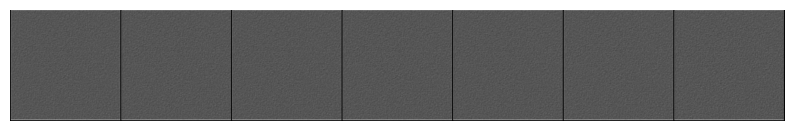

[Epoch 1/150] [D loss: -1674.959961] [G loss: -2830.695557]
[Epoch 2/150] [D loss: -2015.199951] [G loss: -2180.916748]
[Epoch 3/150] [D loss: 36.875488] [G loss: 960.946960]
[Epoch 4/150] [D loss: -1202.895020] [G loss: 189.120193]
[Epoch 5/150] [D loss: -1083.574707] [G loss: -2575.805664]
Generated images shape: torch.Size([7, 1, 256, 256])


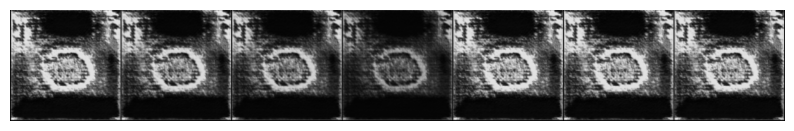

[Epoch 6/150] [D loss: -960.252869] [G loss: -1619.928955]


KeyboardInterrupt: 

In [ ]:
import torch
from torch.autograd import Variable
import numpy as np
import os
from google.colab import drive

# Define save directory inside Google Drive
save_dir = "/content/drive/My Drive/GAN_Weights"
os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist

checkpoint_interval = 10

# Set the device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image shape and model setup
img_shape = (1, img_size, img_size)

# Instantiate models and move them to the GPU
generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
discriminator = Discriminator(img_shape=img_shape).to(device)

# Save initial weights
torch.save(generator.state_dict(), "generator_initial.pth")
torch.save(discriminator.state_dict(), "discriminator_initial.pth")

# Define optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(b1, b2))

# Learning Rate Scheduler (Cosine Annealing)
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=n_epochs)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=n_epochs)

# Gradient penalty function
def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty loss for WGAN GP"""
    alpha = torch.tensor(np.random.random((real_samples.size(0), 1, 1, 1)), dtype=torch.float32, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)

    fake = Variable(torch.ones(real_samples.shape[0], 1, dtype=torch.float32, device=device), requires_grad=False)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# ----------
#  Training
# ----------

batches_done = 0
d_loss_val = 0
g_loss_val = 0

for epoch in range(1, n_epochs + 1):
    if epoch % 5 == 1:
        generate_and_display_images(generator, num_images=7, latent_dim=latent_dim, nrow=7, device=device)
    for i, imgs in enumerate(dataloader):

        # Ensure the tensors are float32 and move to device
        real_imgs = Variable(imgs.type(torch.float32).to(device))

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Sample noise as generator input
        z = Variable(torch.tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim)), dtype=torch.float32).to(device))

        # Generate a batch of images
        fake_imgs = generator(z)

        # Reshape fake images to match the shape of real images
        fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

        # Real images
        real_validity = discriminator(real_imgs)
        # Fake images
        fake_validity = discriminator(fake_imgs)
        # Gradient penalty
        gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, fake_imgs.data)
        # Adversarial loss
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty

        # Apply gradient clipping
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)

        # Backprop and optimizer step
        d_loss.backward()
        d_loss_val = d_loss.item()

        optimizer_D.step()

        optimizer_G.zero_grad()

        # Train the generator every n_critic steps
        if i % n_critic == 0:

            # -----------------
            #  Train Generator
            # -----------------

            # Generate a batch of images
            fake_imgs = generator(z)

            # Reshape fake images to match the shape of real images
            fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

            # Loss measures generator's ability to fool the discriminator
            # Train on fake images
            fake_validity = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_validity)

            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)

            # Backprop and optimizer step
            g_loss.backward()
            optimizer_G.step()

            g_loss_val = g_loss.item()

            if batches_done % sample_interval == 0:
                save_image(fake_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)

            batches_done += 1

        # Step the schedulers (learning rate adjustment)
        scheduler_G.step()
        scheduler_D.step()

    print("[Epoch %d/%d] [D loss: %f] [G loss: %f]"
          % (epoch, n_epochs, d_loss_val, g_loss_val))

# -----------------------
#  Save Model to Drive
# -----------------------

generator_path = os.path.join(save_dir, "generator_final.pth")
discriminator_path = os.path.join(save_dir, "discriminator_final.pth")

torch.save(generator.state_dict(), generator_path)
torch.save(discriminator.state_dict(), discriminator_path)

print(f"Model saved to Google Drive at:\n{generator_path}\n{discriminator_path}")

# ----------------------------
#  Generate and Save Images
# ----------------------------
num_samples = 10  # Number of images to save at the end
z = torch.randn(num_samples, latent_dim, device=device)  # Generate latent vectors
final_images = generator(z).view(num_samples, 1, img_size, img_size)  # Reshape output

# Save each image to Google Drive
for i in range(num_samples):
    save_path = os.path.join(image_save_dir, f"generated_image_{i+1}.png")
    save_image(final_images[i], save_path, normalize=True)

print(f"Final generated images saved to Google Drive at: {image_save_dir}")